#### Importamos las librerias

In [1]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import numpy as np

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 32 # Tamaño del lote para entrenamiento y validación
IMG_SIZE = 224 # Tamaño de las imágenes
LR = 1e-3 # Tasa de aprendizaje
TRAIN_RATIO = 0.8 # Proporción de datos para entrenamiento
SEED = 42 # Semilla para reproducibilidad
EPOCHS = 30 # Número de épocas para entrenamiento

# Configuración de la semilla para reproducibilidad en PyTorch.
# Esto asegura que los resultados sean consistentes entre ejecuciones.
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)


In [6]:
# Transformaciones y Data Augmentation

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=20),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])



In [7]:
# Configuración de los directorios de datos para entrenamiento y prueba.
TRAIN_DIR = "/opt/master/modulo6/Actividades_Modulo6/imagenes_tumores/train"
TEST_DIR = "/opt/master/modulo6/Actividades_Modulo6/imagenes_tumores/test"

# Lectura de las imágenes de entrenamiento y prueba utilizando ImageFolder
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=test_transform)

class_names = train_dataset.classes
num_classes = len(class_names)

# Carga de los datos en DataLoaders
train_loader = DataLoader(train_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=2)

test_loader = DataLoader(test_dataset,
                         batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=2)

dataloaders = {
    "train": train_loader,
    "test": test_loader
}

dataset_sizes = {
    "train": len(train_dataset),
    "test": len(test_dataset)
}


In [ ]:
weights = models.ResNet152_Weights.DEFAULT
model = models.resnet152(weights=weights)

# Congelar todos los pesos originales
for param in model.parameters():
    param.requires_grad = False

# Sustituir cabeza clasificadora
in_features = model.fc.in_features

model.fc = nn.Sequential(nn.Linear(in_features, 256), nn.ReLU6(), nn.Dropout(0.4), nn.Linear(256, num_classes))

class_counts = [360, 300]

weights = torch.tensor([
    1.0, # benign
    360/300 # malignant (más peso)
]).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = optim.AdamW(
    model.fc.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)


Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /home/habib/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:03<00:00, 70.0MB/s] 


In [ ]:
# # Congelar todos los pesos originales
# for param in model.parameters():
#     param.requires_grad = False

# for param in model.layer4.parameters():
#     param.requires_grad = True

# in_features = model.fc.in_features

# model.fc = nn.Sequential(
#     nn.Linear(in_features, 256),
#     nn.ReLU6(),
#     nn.Dropout(0.4),
#     nn.Linear(256, num_classes)
# )

# class_counts = [360, 300]

# weights = torch.tensor([
#     1.0,                 # benign
#     360/300              # malignant (más peso)
# ]).to(device)

# criterion = nn.CrossEntropyLoss(weight=weights)

# optimizer = optim.AdamW(
#     model.fc.parameters(),
#     lr=1e-3,
#     weight_decay=1e-4
# )


In [9]:
def train_model(model, criterion, optimizer, scheduler, dataloaders, dataset_sizes, device, epochs):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    for epoch in range(epochs):
        print(f"\nÉpoca {epoch + 1}/{epochs}")

        for phase in ["train", "test"]:
            if phase == "train":
                model.train()
                grad_ctx = torch.enable_grad()
            else:
                model.eval()
                grad_ctx = torch.no_grad()

            running_loss = 0.0
            running_corrects = 0

            with grad_ctx:
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    if phase == "train":
                        optimizer.zero_grad()

                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += (preds == labels).sum().item()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]

            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)

            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if phase == "test":
                scheduler.step(epoch_acc)

                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_wts)
    print(f"\nMejor precisión en test: {best_acc:.4f}")

    return model, history



Época 1/30
train Loss: 0.4535 Acc: 0.7869
test Loss: 0.4631 Acc: 0.7515

Época 2/30
train Loss: 0.3879 Acc: 0.8184
test Loss: 0.3481 Acc: 0.8470

Época 3/30
train Loss: 0.3495 Acc: 0.8434
test Loss: 0.3325 Acc: 0.8485

Época 4/30
train Loss: 0.3545 Acc: 0.8275
test Loss: 0.3235 Acc: 0.8561

Época 5/30
train Loss: 0.3406 Acc: 0.8373
test Loss: 0.3192 Acc: 0.8576

Época 6/30
train Loss: 0.3249 Acc: 0.8521
test Loss: 0.3218 Acc: 0.8576

Época 7/30
train Loss: 0.2966 Acc: 0.8631
test Loss: 0.3164 Acc: 0.8606

Época 8/30
train Loss: 0.3226 Acc: 0.8487
test Loss: 0.3202 Acc: 0.8712

Época 9/30
train Loss: 0.2969 Acc: 0.8642
test Loss: 0.3092 Acc: 0.8515

Época 10/30
train Loss: 0.3012 Acc: 0.8677
test Loss: 0.3148 Acc: 0.8561

Época 11/30
train Loss: 0.2915 Acc: 0.8623
test Loss: 0.3315 Acc: 0.8273

Época 12/30
train Loss: 0.2712 Acc: 0.8775
test Loss: 0.3069 Acc: 0.8530

Época 13/30
train Loss: 0.2743 Acc: 0.8786
test Loss: 0.3076 Acc: 0.8561

Época 14/30
train Loss: 0.2643 Acc: 0.8821
tes

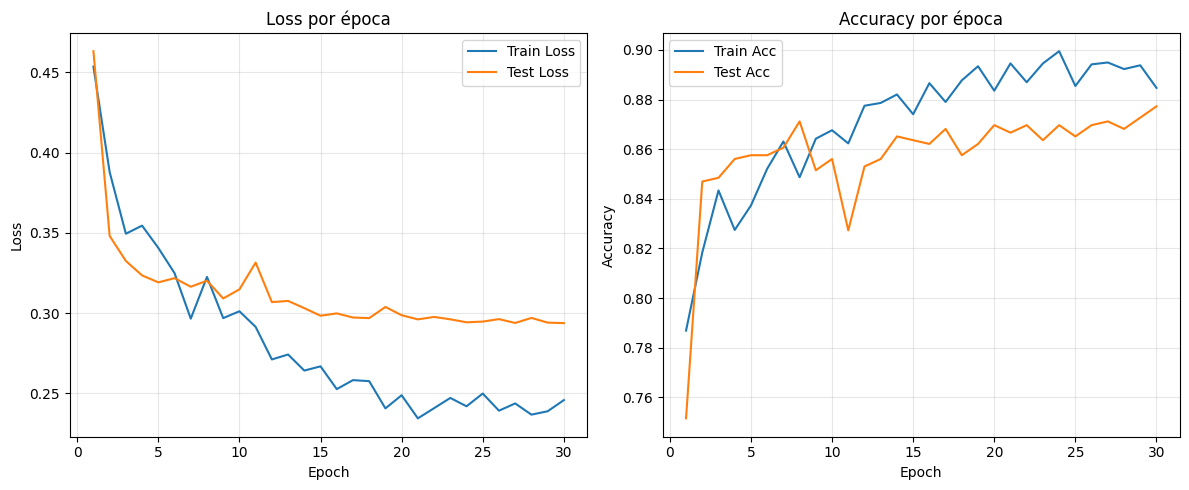

In [10]:
def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["test_loss"], label="Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss por época")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["test_acc"], label="Test Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy por época")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# ======= USO (ajusta a tus variables existentes) =======
# model, criterion, optimizer, dataloaders, dataset_sizes, device, EPOCHS deben existir

model = model.to(device)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",      # porque monitorizamos accuracy
    factor=0.5,
    patience=2
)

model, history = train_model(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    dataloaders=dataloaders,
    dataset_sizes=dataset_sizes,
    device=device,
    epochs=EPOCHS
)

torch.save(model.state_dict(), "resnet18_skin_cancer_transfer_learning.pth")
print("Modelo guardado correctamente.")

plot_history(history)


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model(model, dataloader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print(confusion_matrix(all_labels, all_preds))
    print(classification_report(all_labels, all_preds, target_names=class_names))

evaluate_model(model, test_loader, device, class_names)


In [ ]:

# Red preentrenada ResNet50 con pesos DEFAULT
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

# Congelar todos los pesos originales
for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True



In [ ]:
# Lectura de imágenes en tensores PyTorch
full_dataset = datasets.ImageFolder(
    root=DATA_DIR,
    transform=train_transform
)

# Obtención de las clases presentes en el dataset y el número total de clases. Esto es útil para configurar la capa de salida del modelo y para entender la distribución de las clases en el dataset.
class_names = full_dataset.classes
num_classes = len(class_names)

print("Clases:", class_names)



In [ ]:
# División train / test

train_size = int(TRAIN_RATIO * len(full_dataset))
test_size = len(full_dataset) - train_size

# La función random_split se utiliza para dividir el conjunto de datos completo en conjuntos de entrenamiento y prueba. 
# Se especifica el tamaño de cada conjunto y se utiliza una semilla para garantizar la reproducibilidad de la división.
train_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

# El test no debe usar Data Augmentation
test_dataset.dataset = copy.copy(full_dataset)
test_dataset.dataset.transform = test_transform

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

dataloaders = {
    "train": train_loader,
    "test": test_loader
}

dataset_sizes = {
    "train": len(train_dataset),
    "test": len(test_dataset)
}



In [ ]:

# Red preentrenada ResNet50 con pesos DEFAULT
weights = models.ResNet50_Weights.DEFAULT
model = models.resnet50(weights=weights)

# Congelar todos los pesos originales
for param in model.parameters():
    param.requires_grad = False



In [ ]:
# Sustituir cabeza clasificadora

in_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU6(),
    nn.Dropout(0.4),
    nn.Linear(256, num_classes)
)

# Solo se entrenan las capas nuevas
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=LR
)



In [ ]:
# Entrenamiento y métricas

def train_model(model, criterion, optimizer, dataloaders, dataset_sizes, device, epochs):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    for epoch in range(epochs):
        print(f"\nÉpoca {epoch + 1}/{epochs}")

        for phase in ["train", "test"]:
            if phase == "train":
                model.train()
                grad_ctx = torch.enable_grad()
            else:
                model.eval()
                grad_ctx = torch.no_grad()

            running_loss = 0.0
            running_corrects = 0

            with grad_ctx:
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    if phase == "train":
                        optimizer.zero_grad()

                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += (preds == labels).sum().item()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]

            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)

            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if phase == "test" and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_wts)
    print(f"\nMejor precisión en test: {best_acc:.4f}")

    return model, history


In [ ]:
def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["test_loss"], label="Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss por época")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["test_acc"], label="Test Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy por época")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# ======= USO (ajusta a tus variables existentes) =======
# model, criterion, optimizer, dataloaders, dataset_sizes, device, EPOCHS deben existir

model = model.to(device)

model, history = train_model(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    dataloaders=dataloaders,
    dataset_sizes=dataset_sizes,
    device=device,
    epochs=EPOCHS
)

torch.save(model.state_dict(), "resnet152_diagnostico_tumores.pth")
print("Modelo guardado correctamente.")

plot_history(history)


In [ ]:
print(full_dataset.classes)


In [ ]:
# Class names from the dataset
classes = class_names

# Raw dataset without transforms (returns PIL images)
raw_dataset = datasets.ImageFolder(     
    root=DATA_DIR,
    transform=None
)

def unnormalize(img_tensor):
    # Convert normalized tensor back to image for display
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img_tensor.detach().cpu().numpy().transpose((1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

def show_augmented_vs_original(transform, dataset, num_images=8):
    n = min(num_images, len(dataset))
    indices = np.random.choice(len(dataset), n, replace=False)

    # Get original images (PIL) from dataset
    original_images = [dataset[i][0] for i in indices]

    # Apply augmentations
    augmented_images = [transform(img) for img in original_images]

    fig, axs = plt.subplots(2, n, figsize=(2 * n, 4))
    if n == 1:
        axs = np.array(axs).reshape(2, 1)

    fig.suptitle('Original Images (Top) vs. Augmented Images (Bottom)', fontsize=16)

    for i in range(n):
        # Display original images
        axs[0, i].imshow(original_images[i])
        axs[0, i].axis('off')
        if i == 0:
            axs[0, i].set_ylabel('Original', fontsize=12)

        # Display augmented images (unnormalized tensor)
        img = unnormalize(augmented_images[i])
        axs[1, i].imshow(img)
        axs[1, i].axis('off')
        if i == 0:
            axs[1, i].set_ylabel('Augmented', fontsize=12)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# To use this function, pass your transform pipeline and the raw dataset without transforms:
show_augmented_vs_original(transform=train_transform, dataset=raw_dataset)
